In [ ]:
!pip install --upgrade pyro-ppl imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 98.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninsta

In [ ]:
!pip install laplace-torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.4/67.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.6/196.6 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 108.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 117.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
import laplace
from laplace import Laplace

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split

In [ ]:
df = pd.read_csv("/content/data/Flood Data.csv")

# Combine hazard columns into a single severity measure
df["flood_severity"] = df[["HAZARD 1 IN 30", "HAZARD 1 IN 100", "HAZARD 1 IN 1000"]].max(axis=1)

# Convert flood_severity into binary (1 if >0, else 0)
df["flood_binary"] = (df["flood_severity"] > 0).astype(int)

numeric_cols = [
    "X", "Y", "ELEVATION", "SLOPE", "IMPERVIOUSNESS",
    "NDVI", "DISTANCE TO RIVER", "DISTANCE TO ROAD"
]
categorical_cols = [
    "LANDUSE", "SOIL TYPE", "SUBSTRATE", "BUILDING TYPE"
]

# Convert categorical cols to numeric codes
for col in categorical_cols:
    df[col] = df[col].astype('category').cat.codes

# Fill missing numeric values with mean
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean(numeric_only=True))

# Combine all features
all_features = numeric_cols + categorical_cols
X = df[all_features].values
y = df["flood_binary"].values.astype(np.float32)


In [ ]:
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)


dataset = TensorDataset(X_tensor, y_tensor)


n_total = len(dataset)
n_train = int(0.7 * n_total)
n_val   = n_total - n_train
train_ds, val_ds = random_split(dataset, [n_train, n_val])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)

In [ ]:
class FloodMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=50):
        super().__init__()
        self.hidden = nn.Linear(input_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.hidden(x))
        return self.output(x)

In [ ]:
model = FloodMLP(input_dim=len(all_features), hidden_dim=50)

train_labels = [y.item() for _, y in train_ds]
class_count = np.bincount(train_labels)
total_samples = len(train_labels)
weights_np = [total_samples / c for c in class_count]
class_weights = torch.tensor(weights_np, dtype=torch.float32)
print("Class counts:", class_count)
print("Class weights:", class_weights)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 100



Class counts: [43946  3185]
Class weights: tensor([ 1.0725, 14.7978])


In [ ]:
def train_model(model, loader, epochs):
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for xb, yb in loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        if (epoch+1) % 5 == 0:
            print(f"[Epoch {epoch+1}/{epochs}] Loss: {epoch_loss:.3f}")

train_model(model, train_loader, num_epochs)


[Epoch 5/100] Loss: 38076.589
[Epoch 10/100] Loss: 27055.125
[Epoch 15/100] Loss: 26536.738
[Epoch 20/100] Loss: 20648.765
[Epoch 25/100] Loss: 15724.707
[Epoch 30/100] Loss: 14566.409
[Epoch 35/100] Loss: 9700.636
[Epoch 40/100] Loss: 10557.046
[Epoch 45/100] Loss: 6451.024
[Epoch 50/100] Loss: 6884.085
[Epoch 55/100] Loss: 6291.803
[Epoch 60/100] Loss: 5404.504
[Epoch 65/100] Loss: 4221.195
[Epoch 70/100] Loss: 3542.505
[Epoch 75/100] Loss: 2372.323
[Epoch 80/100] Loss: 1929.975
[Epoch 85/100] Loss: 769.028
[Epoch 90/100] Loss: 266.236
[Epoch 95/100] Loss: 156.012
[Epoch 100/100] Loss: 160.458


In [ ]:
la = Laplace(model, likelihood='classification', subset_of_weights='all', hessian_structure= 'diag')

In [ ]:
la.fit(train_loader, override = True)

In [ ]:
la.optimize_prior_precision(method='marglik')


/usr/local/lib/python3.11/dist-packages/laplace/baselaplace.py:435: UserWarning: By default `link_approx` is `probit`. Make sure to set it equals to the way you want to call `la(test_data, pred_type=..., link_approx=...)`.
  warnings.warn(


In [ ]:
import torch.nn.functional as F
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve)

def evaluate_laplace(la, val_ds, n_samples=10, threshold = 0.4):
    """
    1. Samples from Laplace approximate posterior n_samples times.
    2. Aggregates predictions on the entire val dataset.
    3. Computes classification metrics + average predictive uncertainty.
    """
    la.model.eval()

    all_probs_list = []
    all_targets_list = []

    with torch.no_grad():
      for xb, yb in val_loader:
        xb = xb.float()
        yb = yb.long()

        preds = la.predictive_samples(xb, n_samples = 30)
        probs = F.softmax(preds, dim = -1)
        p_class1 = probs[:, :, 1]

        mean_probs = p_class1.mean(dim=0)

        all_probs_list.append(mean_probs.cpu())
        all_targets_list.append(yb.cpu())

    all_probs_tensor = torch.cat(all_probs_list, dim = 0)
    all_targets_tensor = torch.cat(all_targets_list, dim = 0)

    mean_probs_np = all_probs_tensor.numpy()
    targets_np = all_targets_tensor.numpy()

    y_pred = (mean_probs_np > threshold).astype(int)


    acc = accuracy_score(targets_np, y_pred)
    prec = precision_score(targets_np, y_pred, zero_division=0)
    rec  = recall_score(targets_np, y_pred)
    f1   = f1_score(targets_np, y_pred)


    if len(set(targets_np)) > 1:
        roc_auc = roc_auc_score(targets_np, mean_probs_np)
        pr_auc  = average_precision_score(targets_np, mean_probs_np)
    else:
        roc_auc, pr_auc = float('nan'), float('nan')



    # Print results
    print("Laplace Ensemble Metrics on Validation Set:")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}   Recall: {rec:.3f}   F1: {f1:.3f}")
    print(f"ROC AUC:   {roc_auc:.3f},  PR AUC:  {pr_auc:.3f}")



    return acc, prec, rec, f1, roc_auc, pr_auc, mean_probs_np, targets_np

In [ ]:
results = evaluate_laplace(la, val_loader, n_samples=10)

Laplace Ensemble Metrics on Validation Set:
Accuracy:  0.935
Precision: 0.672   Recall: 0.062   F1: 0.113
ROC AUC:   0.615,  PR AUC:  0.136


In [ ]:
acc, prec, rec, f1, roc_auc, pr_auc, mean_probs_np, targets_np = evaluate_laplace(la, val_loader, n_samples=10)

NameError: name 'la' is not defined

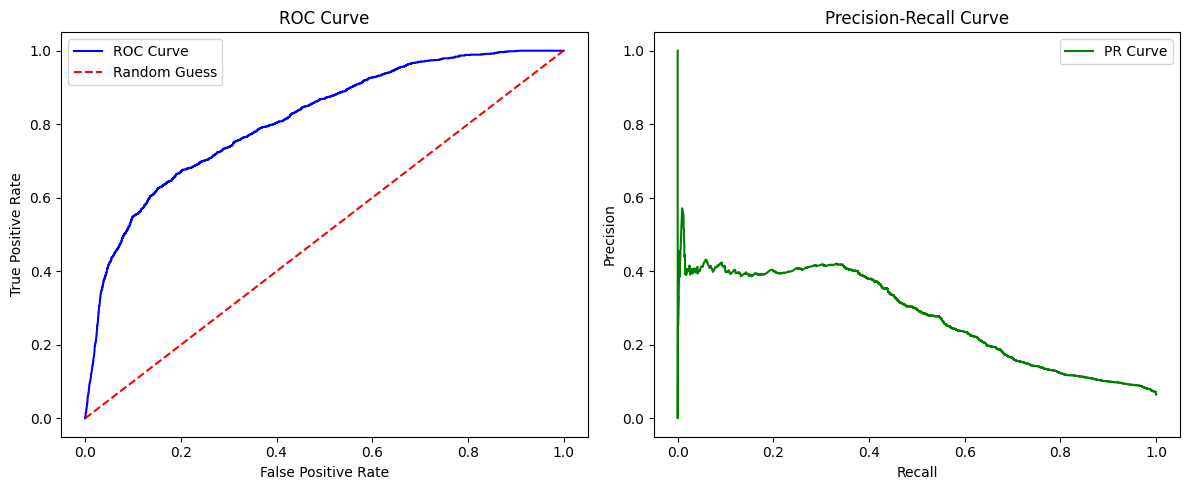

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve


def plot_roc_and_pr(mean_probs, targets):
    """
    mean_probs: numpy array of predicted probabilities for the positive class
    targets:    numpy array of ground truth labels (0 or 1)
    """
    # --- ROC Curve ---
    fpr, tpr, roc_thresholds = roc_curve(targets, mean_probs)


    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label='ROC Curve', color='blue')
    plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()

    # --- Precision-Recall Curve ---
    precision, recall, pr_thresholds = precision_recall_curve(targets, mean_probs)
    plt.subplot(1, 2, 2)
    plt.plot(recall, precision, label='PR Curve', color='green')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()

    plt.tight_layout()
    plt.show()


plot_roc_and_pr(mean_probs_np, targets_np)